In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

In [3]:
record = wfdb.rdrecord('/Users/nayasarianasr/Desktop/ecg_classifier/data/mit-bih-arrhythmia-database-1.0.0/100')
annotation = wfdb.rdann('/Users/nayasarianasr/Desktop/ecg_classifier/data/mit-bih-arrhythmia-database-1.0.0/100', 'atr')

signal = record.p_signal[:, 0]
fs = record.fs

print("Signal length:", len(signal))
print("Sampling rate:", fs)
print("First 5 beat labels:", annotation.symbol[:5])

Signal length: 650000
Sampling rate: 360
First 5 beat labels: ['+', 'N', 'N', 'N', 'N']


Beats for patient #100, to see how many normal , A artrial premature beat,  and V premature ventricular contraction 

In [4]:
import collections

# Count how many of each beat type exist in record 100
label_counts = collections.Counter(annotation.symbol)
print("Beat counts in record 100:")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count} beats")

Beat counts in record 100:
  +: 1 beats
  A: 33 beats
  N: 2239 beats
  V: 1 beats


Plotting raw signal: 
360 Hz 
signal length 65000

plotting for 3600 ms , which is 10 second. we can see 13 R peaks, which would give 78 bom , pretty normal heart beat

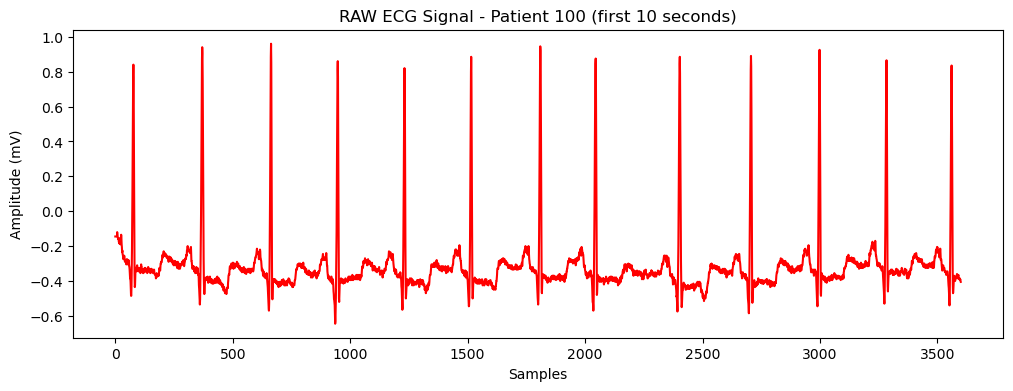

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(signal[:3600], color='red')
plt.title("RAW ECG Signal - Patient 100 (first 10 seconds)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.show()

Noise type : Basseline wander, we have some base at -0.4V (probably due to electrode placement that causes offset)
Patent breathing can cause a non clean signal, we put a high cut at 0.5, and a low cut at 40 hz butter(3, ...) — creates the actual math filter. The 3 means it's a smooth, gradual filter (not a harsh cut)
filtfilt — applies the filter twice, forward and backward, so it doesn't shift the signal in time

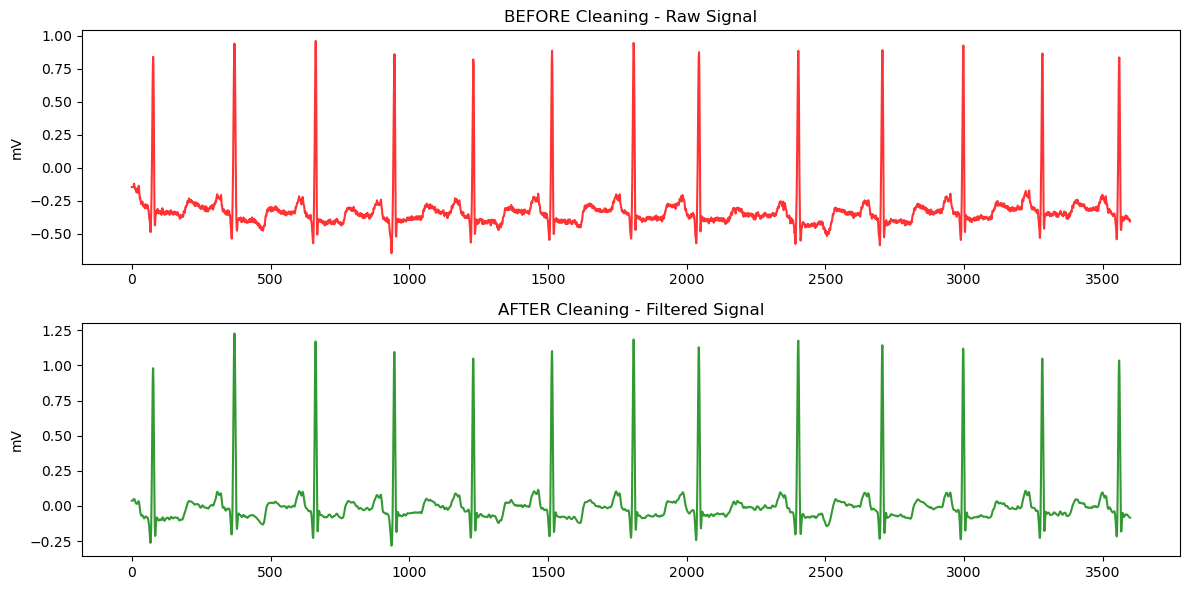

In [6]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360):
    b, a = butter(3, [lowcut / (fs / 2), highcut / (fs / 2)], btype='band')
    return filtfilt(b, a, signal)

clean_signal = bandpass_filter(signal)

# Plot both
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(signal[:3600], color='red', alpha=0.8)
axes[0].set_title("BEFORE Cleaning - Raw Signal")
axes[0].set_ylabel("mV")

axes[1].plot(clean_signal[:3600], color='green', alpha=0.8)
axes[1].set_title("AFTER Cleaning - Filtered Signal")
axes[1].set_ylabel("mV")

plt.tight_layout()
plt.show()

In [7]:
def extract_beats(signal, annotations, window=180):
    beats = []
    labels = []
    
    for i, sample in enumerate(annotations.sample):
        # make sure we don't go out of bounds
        if window < sample < len(signal) - window:
            beat = signal[sample - window : sample + window]
            beats.append(beat)
            labels.append(annotations.symbol[i])
    
    return np.array(beats), np.array(labels)

beats, labels = extract_beats(clean_signal, annotation)

print("Total beats extracted:", len(beats))
print("Shape of beats array:", beats.shape)
print("Example labels:", labels[:10])

Total beats extracted: 2271
Shape of beats array: (2271, 360)
Example labels: ['N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N']


I can see that there are so much more normal than abnormal ,which can cause a class imbalance, later during the machine learning part. 

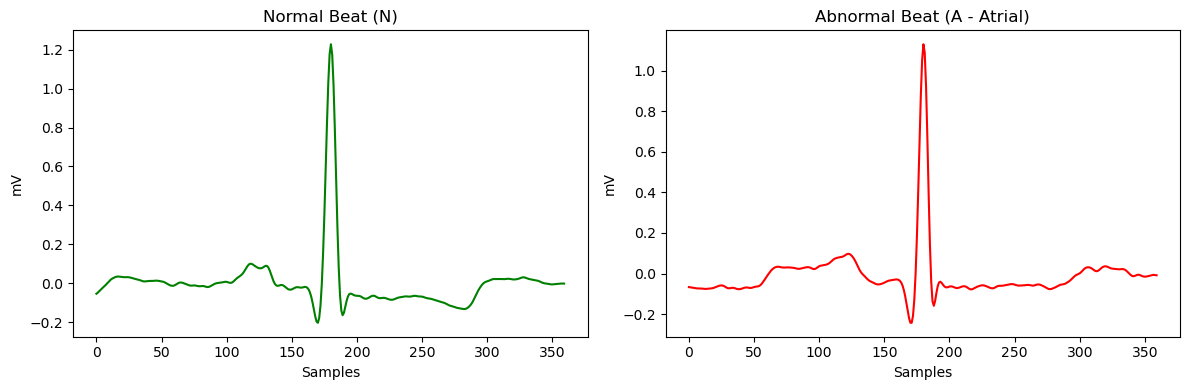

In [8]:
# Find index of a normal and abnormal beat
normal_idx = np.where(labels == 'N')[0][0]
abnormal_idx = np.where(labels == 'A')[0][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(beats[normal_idx], color='green')
axes[0].set_title("Normal Beat (N)")
axes[0].set_ylabel("mV")
axes[0].set_xlabel("Samples")

axes[1].plot(beats[abnormal_idx], color='red')
axes[1].set_title("Abnormal Beat (A - Atrial)")
axes[1].set_ylabel("mV")
axes[1].set_xlabel("Samples")

plt.tight_layout()
plt.show()

We can see that the abnormal beat is up tp 1V instead of 1.2V. 

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Step 1 - keep only common beat types
mask = np.isin(labels, ['N', 'A'])
X = beats[mask]
y = labels[mask]

print("Dataset size:", X.shape)
print("Label counts:", dict(zip(*np.unique(y, return_counts=True))))

# Step 2 - split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# Step 3 - train the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("\nModel trained! ✅")

# Step 4 - test it
y_pred = clf.predict(X_test)
print("\nResults:")
print(classification_report(y_test, y_pred))

Dataset size: (2270, 360)
Label counts: {np.str_('A'): np.int64(33), np.str_('N'): np.int64(2237)}

Training samples: 1816
Testing samples: 454

Model trained! ✅

Results:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         7
           N       1.00      1.00      1.00       447

    accuracy                           1.00       454
   macro avg       1.00      1.00      1.00       454
weighted avg       1.00      1.00      1.00       454



split train vs test on 80 and 20 . 
100 trees

In [12]:
import os

# List of all patient records in the dataset
all_records = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

data_path = '/Users/nayasarianasr/Desktop/ecg_classifier/data/mit-bih-arrhythmia-database-1.0.0/'

all_beats = []
all_labels = []

for rec in all_records:
    try:
        record = wfdb.rdrecord(data_path + rec)
        annotation = wfdb.rdann(data_path + rec, 'atr')
        sig = record.p_signal[:, 0]
        sig = bandpass_filter(sig)
        beats_rec, labels_rec = extract_beats(sig, annotation)
        all_beats.append(beats_rec)
        all_labels.append(labels_rec)
        print(f"✅ Record {rec}: {len(beats_rec)} beats")
    except Exception as e:
        print(f"❌ Record {rec} failed: {e}")

# Combine everything
all_beats = np.concatenate(all_beats)
all_labels = np.concatenate(all_labels)

print("\nTotal beats:", len(all_beats))
import collections
print("Label counts:", collections.Counter(all_labels))

✅ Record 100: 2271 beats
✅ Record 101: 1872 beats
✅ Record 102: 2189 beats
✅ Record 103: 2089 beats
✅ Record 104: 2308 beats
✅ Record 105: 2690 beats
✅ Record 106: 2097 beats
✅ Record 107: 2138 beats
✅ Record 108: 1822 beats
✅ Record 109: 2532 beats
✅ Record 111: 2132 beats
✅ Record 112: 2547 beats
✅ Record 113: 1793 beats
✅ Record 114: 1889 beats
✅ Record 115: 1959 beats
✅ Record 116: 2419 beats
✅ Record 117: 1537 beats
✅ Record 118: 2299 beats
✅ Record 119: 2093 beats
✅ Record 121: 1873 beats
✅ Record 122: 2476 beats
✅ Record 123: 1517 beats
✅ Record 124: 1632 beats
✅ Record 200: 2790 beats
✅ Record 201: 2037 beats
✅ Record 202: 2145 beats
✅ Record 203: 3105 beats
✅ Record 205: 2670 beats
✅ Record 207: 2383 beats
✅ Record 208: 3037 beats
✅ Record 209: 3050 beats
✅ Record 210: 2682 beats
✅ Record 212: 2761 beats
✅ Record 213: 3291 beats
✅ Record 214: 2294 beats
✅ Record 215: 3397 beats
✅ Record 217: 2279 beats
✅ Record 219: 2312 beats
✅ Record 220: 2066 beats
✅ Record 221: 2461 beats


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Keep only the 5 meaningful beat types
mask = np.isin(all_labels, ['N', 'L', 'R', 'V', 'A'])
X = all_beats[mask]
y = all_labels[mask]

print("Dataset size:", X.shape)
print("Label counts:", dict(zip(*np.unique(y, return_counts=True))))

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
print("\nModel trained! ✅")

# Evaluate
y_pred = clf.predict(X_test)
print("\nResults:")
print(classification_report(y_test, y_pred))

Dataset size: (100011, 360)
Label counts: {np.str_('A'): np.int64(2546), np.str_('L'): np.int64(8071), np.str_('N'): np.int64(75011), np.str_('R'): np.int64(7254), np.str_('V'): np.int64(7129)}

Training samples: 80008
Testing samples: 20003

Model trained! ✅

Results:
              precision    recall  f1-score   support

           A       0.98      0.82      0.89       476
           L       1.00      0.99      0.99      1606
           N       0.99      1.00      0.99     15049
           R       1.00      0.99      0.99      1456
           V       0.98      0.97      0.98      1416

    accuracy                           0.99     20003
   macro avg       0.99      0.95      0.97     20003
weighted avg       0.99      0.99      0.99     20003

